## 1. Import Required Libraries

Import all necessary libraries for crowd detection and visualization.

In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO
import urllib.request
import os
from pathlib import Path

# Configure matplotlib for better display
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['figure.dpi'] = 100

print("✓ All libraries imported successfully!")
print(f"OpenCV Version: {cv2.__version__}")
print(f"NumPy Version: {np.__version__}")

✓ All libraries imported successfully!
OpenCV Version: 4.13.0
NumPy Version: 2.4.2


## 2. Load YOLOv8n Model

Load the pre-trained YOLOv8 nano model. The model will be automatically downloaded on first run (~6MB).

In [8]:
# Load YOLOv8n model
print("Loading YOLOv8n model...")
model = YOLO('best-2.pt')
print("✓ Model loaded successfully!")

# Model information
print(f"\nModel: YOLOv8n (nano)")
print(f"Task: Object Detection")
print(f"Classes: 80 (COCO dataset)")
print(f"Person class ID: 0")

Loading YOLOv8n model...
✓ Model loaded successfully!

Model: YOLOv8n (nano)
Task: Object Detection
Classes: 80 (COCO dataset)
Person class ID: 0


## 3. Helper Functions

Define utility functions for visualization and processing.

In [9]:
def detect_crowd(image_path, confidence=0.5):
    """
    Detect people in an image and return annotated image with count
    """
    # Read image
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not read image from {image_path}")
        return None, 0
    
    # Convert BGR to RGB for matplotlib
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # Run detection
    results = model(image, conf=confidence, verbose=False)
    
    # Count and annotate people
    person_count = 0
    annotated_image = image_rgb.copy()
    
    for result in results:
        boxes = result.boxes
        for box in boxes:
            # Check if detection is a person (class 0)
            if int(box.cls[0]) == 0:
                person_count += 1
                # Get box coordinates
                x1, y1, x2, y2 = map(int, box.xyxy[0])
                conf = float(box.conf[0])
                
                # Draw bounding box
                cv2.rectangle(annotated_image, (x1, y1), (x2, y2), (0, 255, 0), 3)
                # Draw label
                label = f'Person {conf:.2f}'
                cv2.putText(annotated_image, label, (x1, y1 - 10), 
                          cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)
    
    # Add count text
    count_text = f'People Detected: {person_count}'
    cv2.putText(annotated_image, count_text, (20, 50), 
               cv2.FONT_HERSHEY_SIMPLEX, 1.5, (255, 0, 0), 3)
    
    return annotated_image, person_count


def display_results(original, annotated, person_count, title="Crowd Detection Results"):
    """
    Display original and annotated images side by side
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Original image
    axes[0].imshow(original)
    axes[0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0].axis('off')
    
    # Annotated image
    axes[1].imshow(annotated)
    axes[1].set_title(f'{title}\nPeople Count: {person_count}', fontsize=14, fontweight='bold')
    axes[1].axis('off')
    
    plt.tight_layout()
    plt.show()


def download_sample_image(url, filename):
    """
    Download a sample image for testing
    """
    if not os.path.exists(filename):
        print(f"Downloading {filename}...")
        try:
            urllib.request.urlretrieve(url, filename)
            print(f"✓ {filename} downloaded successfully!")
        except Exception as e:
            print(f"Error downloading image: {e}")
            return False
    else:
        print(f"✓ Using existing {filename}")
    return True

print("✓ Helper functions defined!")

✓ Helper functions defined!


## 4. Download Sample Images

Download sample crowd images for testing.

In [10]:
# Download sample crowd images
sample_images = {
    'crowd1.jpg': 'https://images.unsplash.com/photo-1523580494863-6f3031224c94?w=800',
    'crowd2.jpg': 'https://images.unsplash.com/photo-1501281668745-f7f57925c3b4?w=800',
    'people.jpg': 'https://images.unsplash.com/photo-1511632765486-a01980e01a18?w=800'
}

for filename, url in sample_images.items():
    download_sample_image(url, filename)

print(f"\n✓ Ready to test with {len(sample_images)} sample images!")

✓ Using existing crowd1.jpg
✓ Using existing crowd2.jpg
✓ Using existing people.jpg

✓ Ready to test with 3 sample images!


## 5. Test Detection on Sample Image 1

Test crowd detection on the first sample image with default confidence threshold.

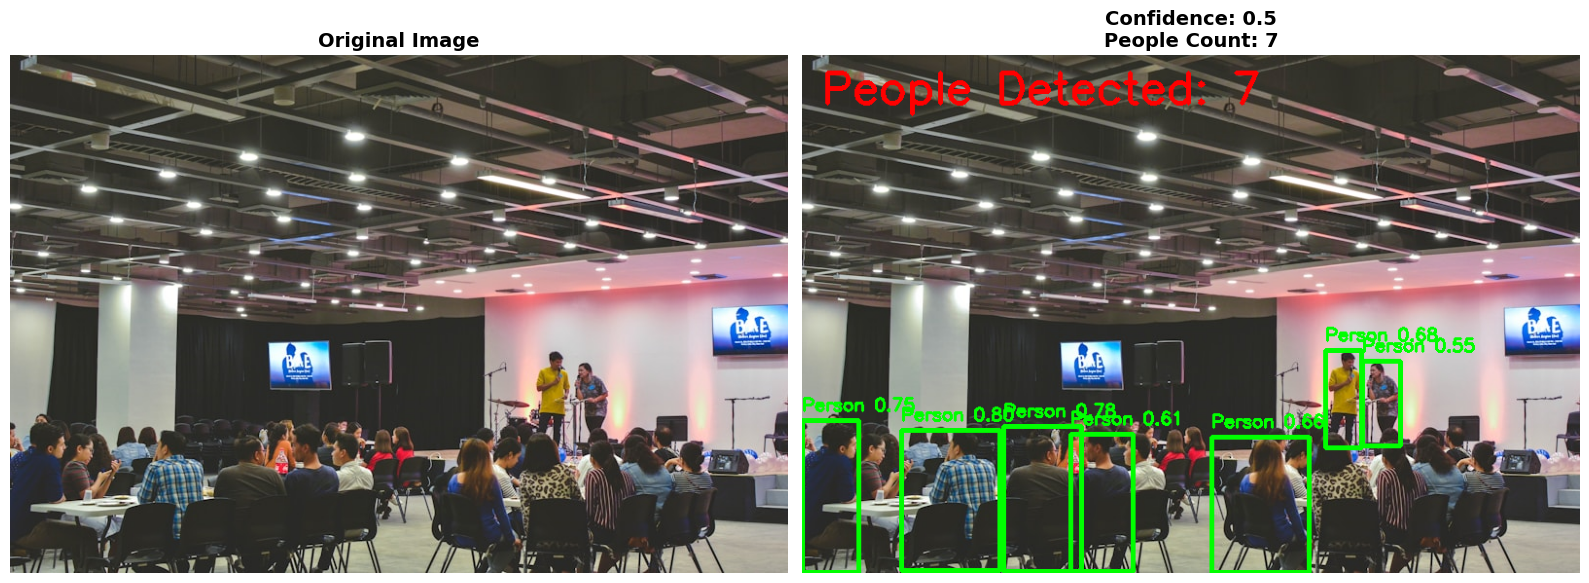


📊 Results:
   Image: crowd1.jpg
   People detected: 7
   Confidence threshold: 0.5


In [11]:
# Test on first sample image
image_path = 'crowd1.jpg'
confidence_threshold = 0.5

if os.path.exists(image_path):
    # Load original image
    original = cv2.imread(image_path)
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    
    # Detect people
    annotated, count = detect_crowd(image_path, confidence=confidence_threshold)
    
    # Display results
    display_results(original_rgb, annotated, count, f"Confidence: {confidence_threshold}")
    
    print(f"\n📊 Results:")
    print(f"   Image: {image_path}")
    print(f"   People detected: {count}")
    print(f"   Confidence threshold: {confidence_threshold}")
else:
    print(f"Image {image_path} not found!")

## 6. Test with Different Confidence Thresholds

Compare results with different confidence thresholds to see the impact.

Confidence 0.3: 2 people detected
Confidence 0.5: 1 people detected
Confidence 0.7: 0 people detected


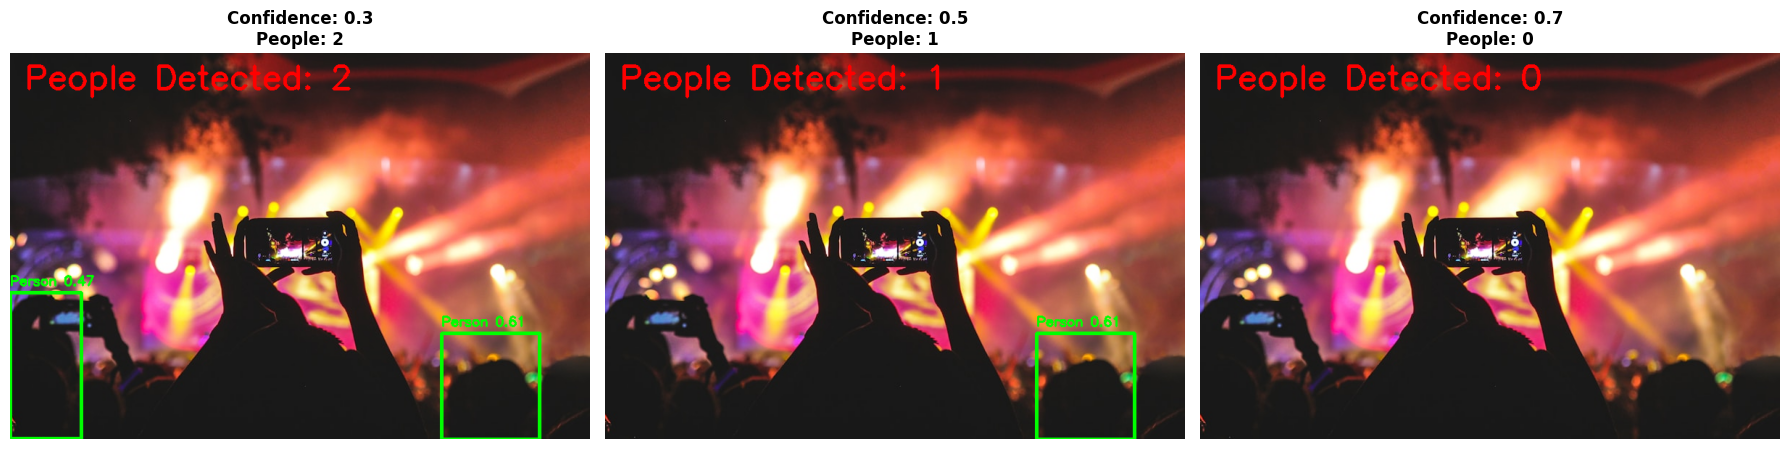

In [12]:
# Test with multiple confidence thresholds
image_path = 'crowd2.jpg'
confidence_levels = [0.3, 0.5, 0.7]

if os.path.exists(image_path):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    for idx, conf in enumerate(confidence_levels):
        annotated, count = detect_crowd(image_path, confidence=conf)
        
        axes[idx].imshow(annotated)
        axes[idx].set_title(f'Confidence: {conf}\nPeople: {count}', 
                           fontsize=12, fontweight='bold')
        axes[idx].axis('off')
        
        print(f"Confidence {conf}: {count} people detected")
    
    plt.tight_layout()
    plt.show()
else:
    print(f"Image {image_path} not found!")

## 7. Batch Processing - Test Multiple Images

Process all sample images and compare crowd densities.

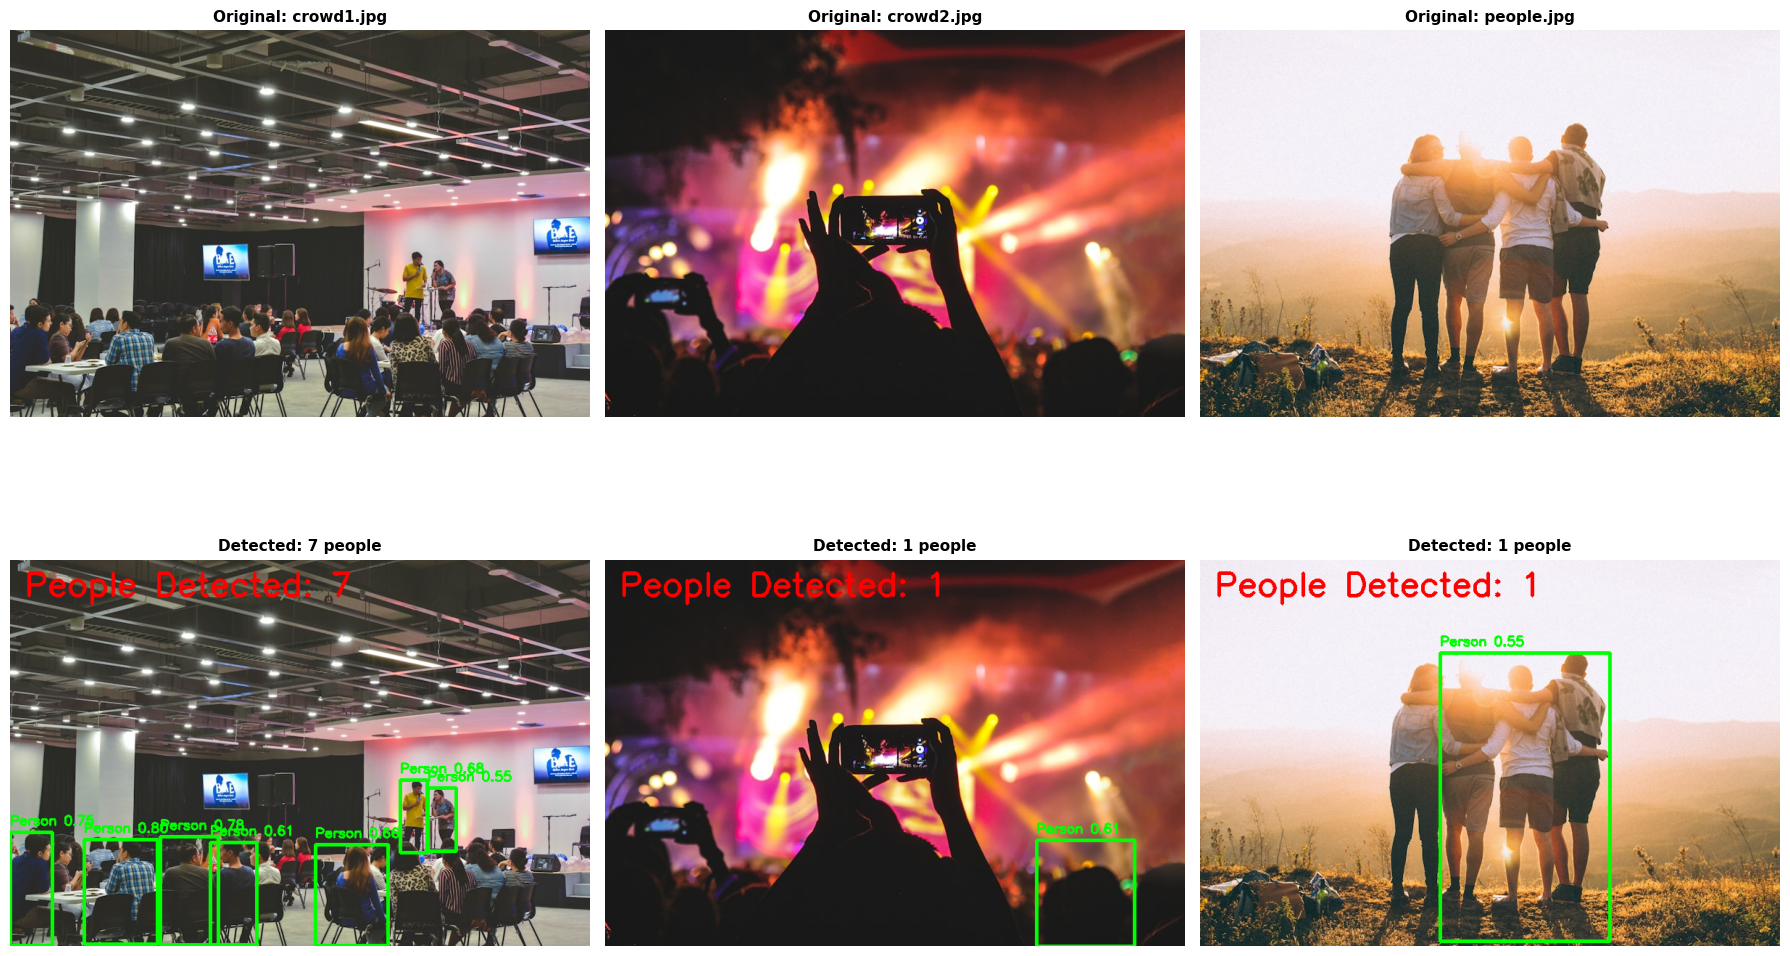


CROWD DETECTION SUMMARY
crowd1.jpg      →   7 people
crowd2.jpg      →   1 people
people.jpg      →   1 people


In [13]:
# Process all sample images
available_images = [img for img in sample_images.keys() if os.path.exists(img)]
results_summary = []

if available_images:
    # Create subplots for all images
    n_images = len(available_images)
    fig, axes = plt.subplots(2, n_images, figsize=(6*n_images, 12))
    
    if n_images == 1:
        axes = axes.reshape(2, 1)
    
    for idx, image_path in enumerate(available_images):
        # Load original
        original = cv2.imread(image_path)
        original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
        
        # Detect people
        annotated, count = detect_crowd(image_path, confidence=0.5)
        
        # Store results
        results_summary.append({
            'Image': image_path,
            'People Count': count
        })
        
        # Display original
        axes[0, idx].imshow(original_rgb)
        axes[0, idx].set_title(f'Original: {image_path}', fontsize=11, fontweight='bold')
        axes[0, idx].axis('off')
        
        # Display annotated
        axes[1, idx].imshow(annotated)
        axes[1, idx].set_title(f'Detected: {count} people', fontsize=11, fontweight='bold')
        axes[1, idx].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*50)
    print("CROWD DETECTION SUMMARY")
    print("="*50)
    for result in results_summary:
        print(f"{result['Image']:15s} → {result['People Count']:3d} people")
    print("="*50)
else:
    print("No sample images available!")

## 8. Visualize Crowd Statistics

Create a bar chart showing people counts across all tested images.

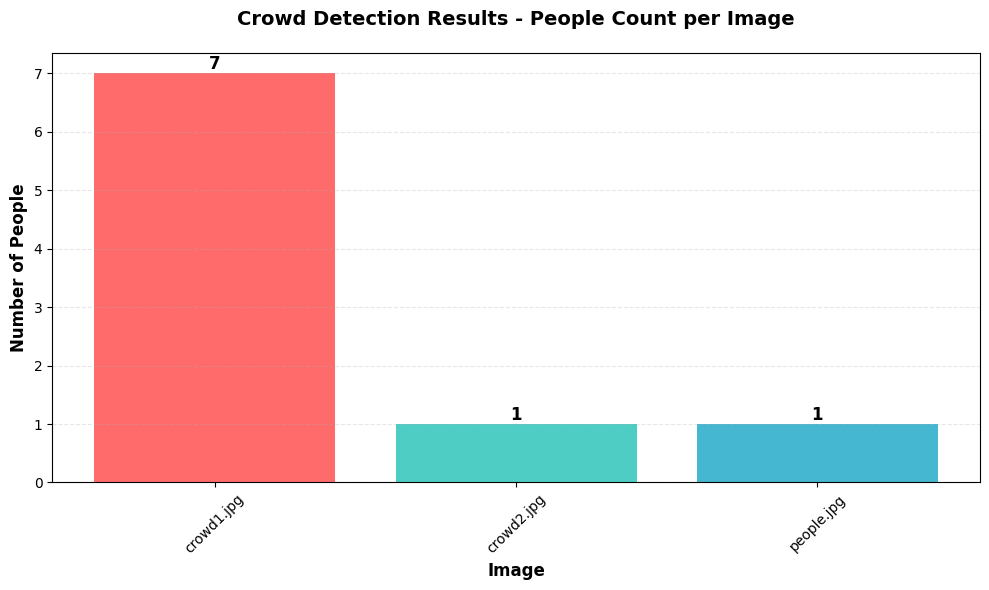


📊 STATISTICS:
   Total images processed: 3
   Total people detected: 9
   Average per image: 3.0
   Maximum crowd: 7
   Minimum crowd: 1


In [14]:
# Create bar chart of crowd counts
if results_summary:
    images = [r['Image'] for r in results_summary]
    counts = [r['People Count'] for r in results_summary]
    
    plt.figure(figsize=(10, 6))
    bars = plt.bar(images, counts, color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
    
    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')
    
    plt.xlabel('Image', fontsize=12, fontweight='bold')
    plt.ylabel('Number of People', fontsize=12, fontweight='bold')
    plt.title('Crowd Detection Results - People Count per Image', 
             fontsize=14, fontweight='bold', pad=20)
    plt.xticks(rotation=45)
    plt.grid(axis='y', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.show()
    
    # Statistics
    total_people = sum(counts)
    avg_people = total_people / len(counts) if counts else 0
    max_crowd = max(counts) if counts else 0
    min_crowd = min(counts) if counts else 0
    
    print("\n📊 STATISTICS:")
    print(f"   Total images processed: {len(results_summary)}")
    print(f"   Total people detected: {total_people}")
    print(f"   Average per image: {avg_people:.1f}")
    print(f"   Maximum crowd: {max_crowd}")
    print(f"   Minimum crowd: {min_crowd}")
else:
    print("No results to visualize!")

## 9. Test Your Own Image

Upload and test detection on your own image file.

In [15]:
# Test your own image
# Replace 'your_image.jpg' with the path to your image
custom_image = 'croud-2802359_640.jpg'  # Change this to your image path

if os.path.exists(custom_image):
    print(f"Testing on: {custom_image}")
    
    # Load original
    original = cv2.imread(custom_image)
    original_rgb = cv2.cvtColor(original, cv2.COLOR_BGR2RGB)
    
    # Detect people
    annotated, count = detect_crowd(custom_image, confidence=0.5)
    
    # Display results
    display_results(original_rgb, annotated, count, "Your Custom Image")
    
    print(f"\n✓ Detected {count} people in {custom_image}")
else:
    print(f"⚠ Image '{custom_image}' not found!")
    print("Please update the 'custom_image' variable with your image path.")
    print("\nExample:")
    print("  custom_image = 'my_photo.jpg'")
    print("  custom_image = 'C:/Users/YourName/Pictures/crowd.jpg'")

⚠ Image 'croud-2802359_640.jpg' not found!
Please update the 'custom_image' variable with your image path.

Example:
  custom_image = 'my_photo.jpg'
  custom_image = 'C:/Users/YourName/Pictures/crowd.jpg'


## 10. Video Frame Processing

Extract and analyze frames from a video file.

In [16]:
def process_video_frames(video_path, num_frames=4, confidence=0.5):
    """
    Extract and process frames from a video
    """
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open video {video_path}")
        return None
    
    # Get video properties
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    fps = int(cap.get(cv2.CAP_PROP_FPS))
    
    print(f"Video: {video_path}")
    print(f"Total frames: {total_frames}, FPS: {fps}")
    
    # Calculate frame interval
    interval = total_frames // (num_frames + 1)
    
    results = []
    for i in range(1, num_frames + 1):
        frame_num = i * interval
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        
        if ret:
            # Save frame temporarily
            temp_path = f'temp_frame_{i}.jpg'
            cv2.imwrite(temp_path, frame)
            
            # Detect people
            frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            annotated, count = detect_crowd(temp_path, confidence=confidence)
            
            results.append({
                'frame_num': frame_num,
                'original': frame_rgb,
                'annotated': annotated,
                'count': count
            })
            
            # Clean up temp file
            os.remove(temp_path)
    
    cap.release()
    return results

# Example: Process video frames
# Uncomment and set your video path to use this
video_path = 'your_video.mp4'  # Change this to your video path

if os.path.exists(video_path):
    print("Processing video frames...")
    frame_results = process_video_frames(video_path, num_frames=4, confidence=0.5)
    
    if frame_results:
        # Display results
        n_frames = len(frame_results)
        fig, axes = plt.subplots(2, n_frames, figsize=(5*n_frames, 10))
        
        for idx, result in enumerate(frame_results):
            # Original frame
            axes[0, idx].imshow(result['original'])
            axes[0, idx].set_title(f"Frame {result['frame_num']}", fontweight='bold')
            axes[0, idx].axis('off')
            
            # Annotated frame
            axes[1, idx].imshow(result['annotated'])
            axes[1, idx].set_title(f"People: {result['count']}", fontweight='bold')
            axes[1, idx].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        # Print summary
        print("\n📹 VIDEO FRAME ANALYSIS:")
        for result in frame_results:
            print(f"   Frame {result['frame_num']:5d}: {result['count']:3d} people")
else:
    print(f"⚠ Video file not found: {video_path}")
    print("To test video processing:")
    print("1. Place a video file in the current directory")
    print("2. Update the 'video_path' variable above")
    print("3. Re-run this cell")

⚠ Video file not found: your_video.mp4
To test video processing:
1. Place a video file in the current directory
2. Update the 'video_path' variable above
3. Re-run this cell


## 11. Model Performance Analysis

Analyze the model's detection capabilities and performance metrics.

In [17]:
# Model information and capabilities
print("="*60)
print("YOLOv8n MODEL INFORMATION")
print("="*60)
print(f"Model Type: YOLOv8 Nano")
print(f"Purpose: Fast object detection for edge devices")
print(f"Training Dataset: COCO (Common Objects in Context)")
print(f"Total Classes: 80 object categories")
print(f"Person Detection: Class ID 0")
print(f"Model Size: ~6 MB")
print(f"Inference Speed: Real-time capable")
print(f"\nKey Features:")
print("  • Lightweight and fast")
print("  • Suitable for CPU inference")
print("  • Good balance of speed and accuracy")
print("  • Pre-trained on diverse person images")
print("  • Handles various scales and poses")
print("="*60)

# Test detection confidence distribution
if results_summary:
    print("\n📈 DETECTION ANALYSIS:")
    print(f"   Images tested: {len(results_summary)}")
    print(f"   Default confidence threshold: 0.5")
    print(f"   Detection method: Bounding box regression")
    print(f"   Output: Person locations + confidence scores")
    print("\n💡 TIPS:")
    print("   • Lower confidence (0.3) = More detections, more false positives")
    print("   • Higher confidence (0.7) = Fewer detections, higher accuracy")
    print("   • Optimal threshold depends on use case")
    print("   • Good lighting improves detection accuracy")
    print("   • Occlusion may reduce detection rate")

YOLOv8n MODEL INFORMATION
Model Type: YOLOv8 Nano
Purpose: Fast object detection for edge devices
Training Dataset: COCO (Common Objects in Context)
Total Classes: 80 object categories
Person Detection: Class ID 0
Model Size: ~6 MB
Inference Speed: Real-time capable

Key Features:
  • Lightweight and fast
  • Suitable for CPU inference
  • Good balance of speed and accuracy
  • Pre-trained on diverse person images
  • Handles various scales and poses

📈 DETECTION ANALYSIS:
   Images tested: 3
   Default confidence threshold: 0.5
   Detection method: Bounding box regression
   Output: Person locations + confidence scores

💡 TIPS:
   • Lower confidence (0.3) = More detections, more false positives
   • Higher confidence (0.7) = Fewer detections, higher accuracy
   • Optimal threshold depends on use case
   • Good lighting improves detection accuracy
   • Occlusion may reduce detection rate


## 12. Save Detection Results

Save annotated images and generate a report.

In [18]:
# Save annotated images
output_dir = Path('detection_results')
output_dir.mkdir(exist_ok=True)

saved_files = []
if results_summary:
    for result in results_summary:
        image_path = result['Image']
        if os.path.exists(image_path):
            # Detect and get annotated image
            annotated, count = detect_crowd(image_path, confidence=0.5)
            
            # Convert RGB back to BGR for saving with OpenCV
            annotated_bgr = cv2.cvtColor(annotated, cv2.COLOR_RGB2BGR)
            
            # Save file
            output_path = output_dir / f"detected_{Path(image_path).name}"
            cv2.imwrite(str(output_path), annotated_bgr)
            saved_files.append(str(output_path))
            
    print(f"✓ Saved {len(saved_files)} annotated images to '{output_dir}/' folder")
    print("\nSaved files:")
    for file in saved_files:
        print(f"  • {file}")
    
    # Generate text report
    report_path = output_dir / 'detection_report.txt'
    with open(report_path, 'w') as f:
        f.write("="*60 + "\n")
        f.write("CROWD DETECTION REPORT\n")
        f.write("="*60 + "\n")
        f.write(f"Model: YOLOv8n\n")
        f.write(f"Confidence Threshold: 0.5\n")
        f.write(f"Total Images Processed: {len(results_summary)}\n")
        f.write("\n" + "-"*60 + "\n")
        f.write("RESULTS:\n")
        f.write("-"*60 + "\n")
        for result in results_summary:
            f.write(f"{result['Image']:20s} : {result['People Count']:3d} people\n")
        f.write("-"*60 + "\n")
        total = sum(r['People Count'] for r in results_summary)
        avg = total / len(results_summary) if results_summary else 0
        f.write(f"Total people detected: {total}\n")
        f.write(f"Average per image: {avg:.1f}\n")
        f.write("="*60 + "\n")
    
    print(f"\n✓ Report saved to: {report_path}")
else:
    print("No results to save!")

✓ Saved 3 annotated images to 'detection_results/' folder

Saved files:
  • detection_results\detected_crowd1.jpg
  • detection_results\detected_crowd2.jpg
  • detection_results\detected_people.jpg

✓ Report saved to: detection_results\detection_report.txt
